## Quantum Battleships

You're given an **8x8 Battleships board** with some squares containing ship segments.  
Classically, finding the ships takes on the order of **$n^2 = 64$** checks.

**Challenge:**  
Use a **quantum algorithm** to find the ship squares using **fewer effective queries** than classical search.

You will:
- Treat the 8x8 board as a quantum search space.
- Encode the marked ship squares in a way your circuit can use.
- Design and optimize your algorithm so that, after measurement, the probability of hitting a ship square is as high as possible for as **few oracle calls / iterations** as possible.

**Goal:**  
Build the **best “quantum radar” for Battleships** — highest success probability for the lowest cost.


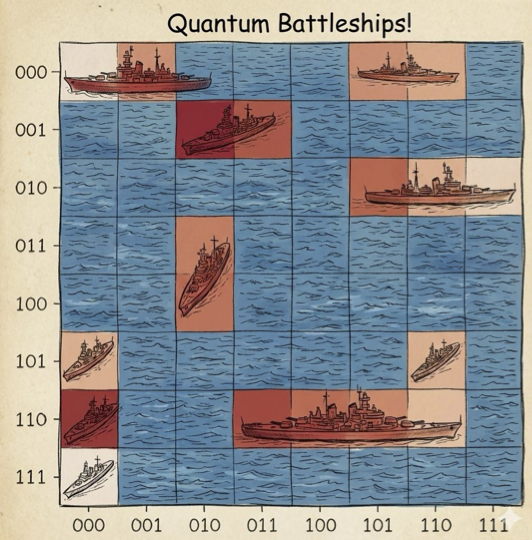

# Install required libraries and useful packages

In [ ]:
# Installing the required libraries

# Install Qiskit and upgrade to the latest version
%pip install qiskit --upgrade

# Install the Qiskit Aer library for simulation
%pip install qiskit qiskit-aer --upgrade

# Install Qiskit visualization tools
%pip install qiskit[visualization] --upgrade

# Install Qiskit visualization tools
%pip install qiskit_ibm_runtime

%pip install qiskit-aer


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=f328c1360a2117f0cdceec35aade2ed27392e109791ceed1e7a9a473e0414a95
  Stored in directory: /root/.cache/pip/wheels/06/3e/78/fa1588c1ae991bbfd814af2bcac6cef7a178beee1939180d46
Successfully built pylatexenc
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 378.5/378.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
# Helpful libraries

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.circuit.library import grover_operator, MCMTGate, ZGate
from qiskit.quantum_info import Pauli, SparsePauliOp, Statevector
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit_aer import AerSimulator
from qiskit.circuit import Parameter, ParameterVector
import qiskit.qasm3
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_bloch_vector
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

from qiskit import transpile
from qiskit_aer import Aer

%config InlineBackend.figure_format = 'retina'

# Encode the marked ship locations in a way your quantum circuit can use

In [ ]:
def generate_field(positions: list[str]) -> QuantumCircuit:
  qc = QuantumCircuit(6)

  vector = np.zeros(2**6)
  amplitude = 1 / np.sqrt(len(positions))
  for pos in positions:
      index = int(pos, 2)
      vector[index] = amplitude

  qc.initialize(vector, range(6))
  return qc

In [ ]:
from random import randint
import math

In [ ]:
def generate_positions(n: int, max_num: int = 63, bits: int = 6) -> list[str]:
  positions = []
  format_string = f"{{0:0{bits}b}}"
  for _ in range(n):
    pos = format_string.format(randint(0, max_num))
    while pos in positions:
      pos = format_string.format(randint(0, max_num))
    positions.append(pos)
  return positions

In [ ]:
from qiskit.circuit.library import DiagonalGate

In [ ]:
def create_multi_target_oracle(targets: list[str]):
    """Creates an oracle that flips the phase of multiple target bitstrings."""
    num_qubits = len(targets[0])
    qc = QuantumCircuit(num_qubits)

    oracle_matrix = np.ones(2**num_qubits)
    for target in targets:
        idx = int(target, 2)
        oracle_matrix[idx] = -1

    qc.append(DiagonalGate(oracle_matrix.tolist()), range(num_qubits))
    return qc

In [ ]:
num_positions = 15
positions = generate_positions(num_positions, max_num=255, bits=8)

In [ ]:
def grover_operator_custom(oracle: QuantumCircuit):
  n_q = oracle.num_qubits
  q_list = list(range(n_q))
  qc = QuantumCircuit(n_q)
  # S_f
  qc.compose(oracle, inplace=True)
  # H
  qc.h(q_list)
  # Zero reflection, S_0
  qc.x(q_list) # 000 -> 111 | 111 -> 000
  qc.h(n_q - 1) # 111 -> 110 - 111 | 000 -> 000 + 001 = 00 (0 + 1)
  qc.mcx(list(range(n_q - 1)), n_q - 1) # 110 - 111 -> 111 - 110 = 11 (1 - 0) | 00 (0 + 1) -> 00 (0 + 1)
  qc.h(n_q - 1) # 11 (1 - 0) -> -111 | 00 (0 + 1) -> 000
  qc.x(q_list) # -000 | 111
  # H
  qc.h(q_list)

  return qc



[14, 18, 25, 60, 66, 72, 124, 141, 151, 172, 185, 197, 227, 242, 248]


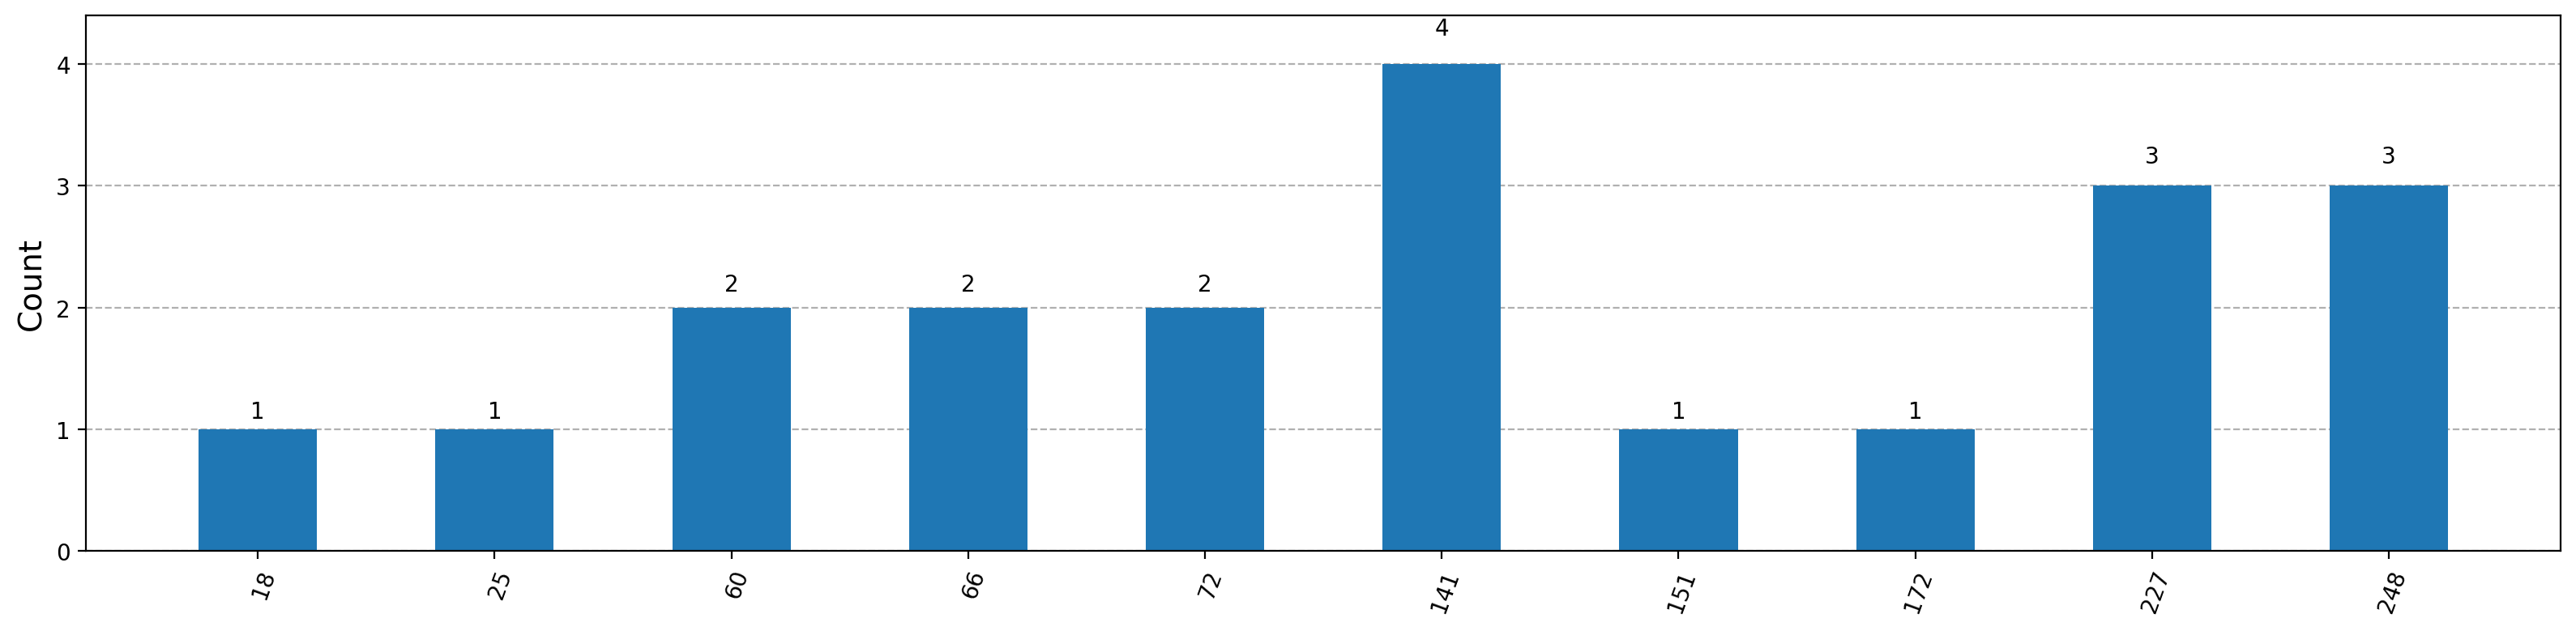

In [ ]:
# qc = generate_field(['000011', '000100', '010000', '001010'])
# qc = generate_field(positions)

qc = QuantumCircuit(8)
qc.h(range(8))

# grover_op = grover_operator(create_multi_target_oracle(['100000', '111111']))
# grover_op = grover_operator(create_multi_target_oracle(positions))
grover_op = grover_operator_custom(create_multi_target_oracle(positions))

for i in range(3):
  qc.append(grover_op, range(8))

qc.measure_all()

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=20)
result = job.result()

counts = result.get_counts()
labels = [int(el, 2) for el in set(positions)]
labels.sort()
print(labels)
plot_histogram({int(el, 2) : val for el, val in counts.items()}, figsize=(16, 4))

In [ ]:
print(qc)

        ┌───┐┌────┐┌────┐┌────┐ ░ ┌─┐               
   q_0: ┤ H ├┤0   ├┤0   ├┤0   ├─░─┤M├───────────────
        ├───┤│    ││    ││    │ ░ └╥┘┌─┐            
   q_1: ┤ H ├┤1   ├┤1   ├┤1   ├─░──╫─┤M├────────────
        ├───┤│    ││    ││    │ ░  ║ └╥┘┌─┐         
   q_2: ┤ H ├┤2   ├┤2   ├┤2   ├─░──╫──╫─┤M├─────────
        ├───┤│  Q ││  Q ││  Q │ ░  ║  ║ └╥┘┌─┐      
   q_3: ┤ H ├┤3   ├┤3   ├┤3   ├─░──╫──╫──╫─┤M├──────
        ├───┤│    ││    ││    │ ░  ║  ║  ║ └╥┘┌─┐   
   q_4: ┤ H ├┤4   ├┤4   ├┤4   ├─░──╫──╫──╫──╫─┤M├───
        ├───┤│    ││    ││    │ ░  ║  ║  ║  ║ └╥┘┌─┐
   q_5: ┤ H ├┤5   ├┤5   ├┤5   ├─░──╫──╫──╫──╫──╫─┤M├
        └───┘└────┘└────┘└────┘ ░  ║  ║  ║  ║  ║ └╥┘
meas: 6/═══════════════════════════╩══╩══╩══╩══╩══╩═
                                   0  1  2  3  4  5 


# Design your algorithm

{'0 1': 236, '1 1': 262, '0 0': 252, '1 0': 274}


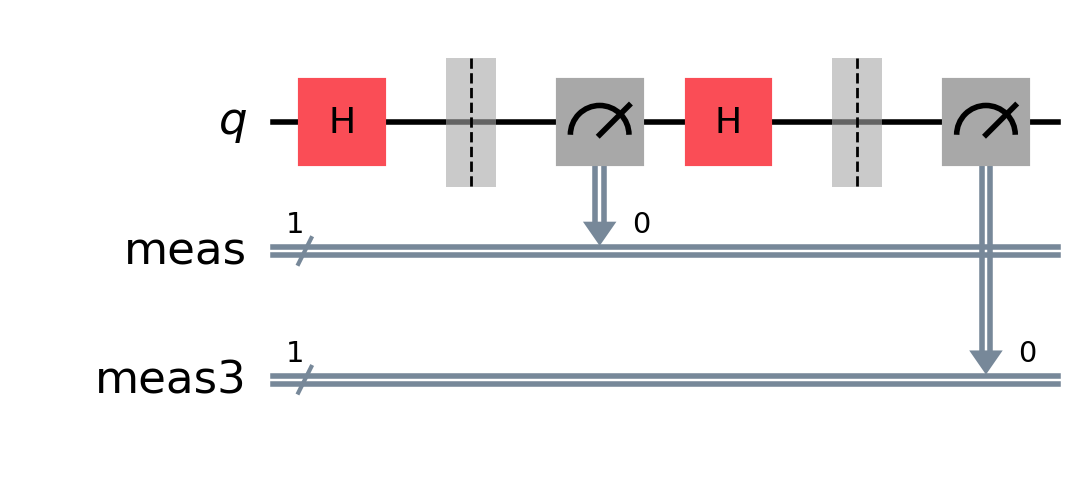

In [ ]:
qc = QuantumCircuit(1)
qc.h(0)
qc.measure_all()
qc.h(0)
qc.measure_all()

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

print(result.get_counts())
display(qc.draw('mpl'))

In [ ]:
def tester(bomb):
  pass

In [ ]:
num_positions = 20
positions = generate_positions(num_positions, max_num=63, bits=8)

[6, 7, 15, 17, 18, 19, 20, 22, 27, 29, 31, 32, 39, 41, 42, 47, 55, 57, 58, 63]


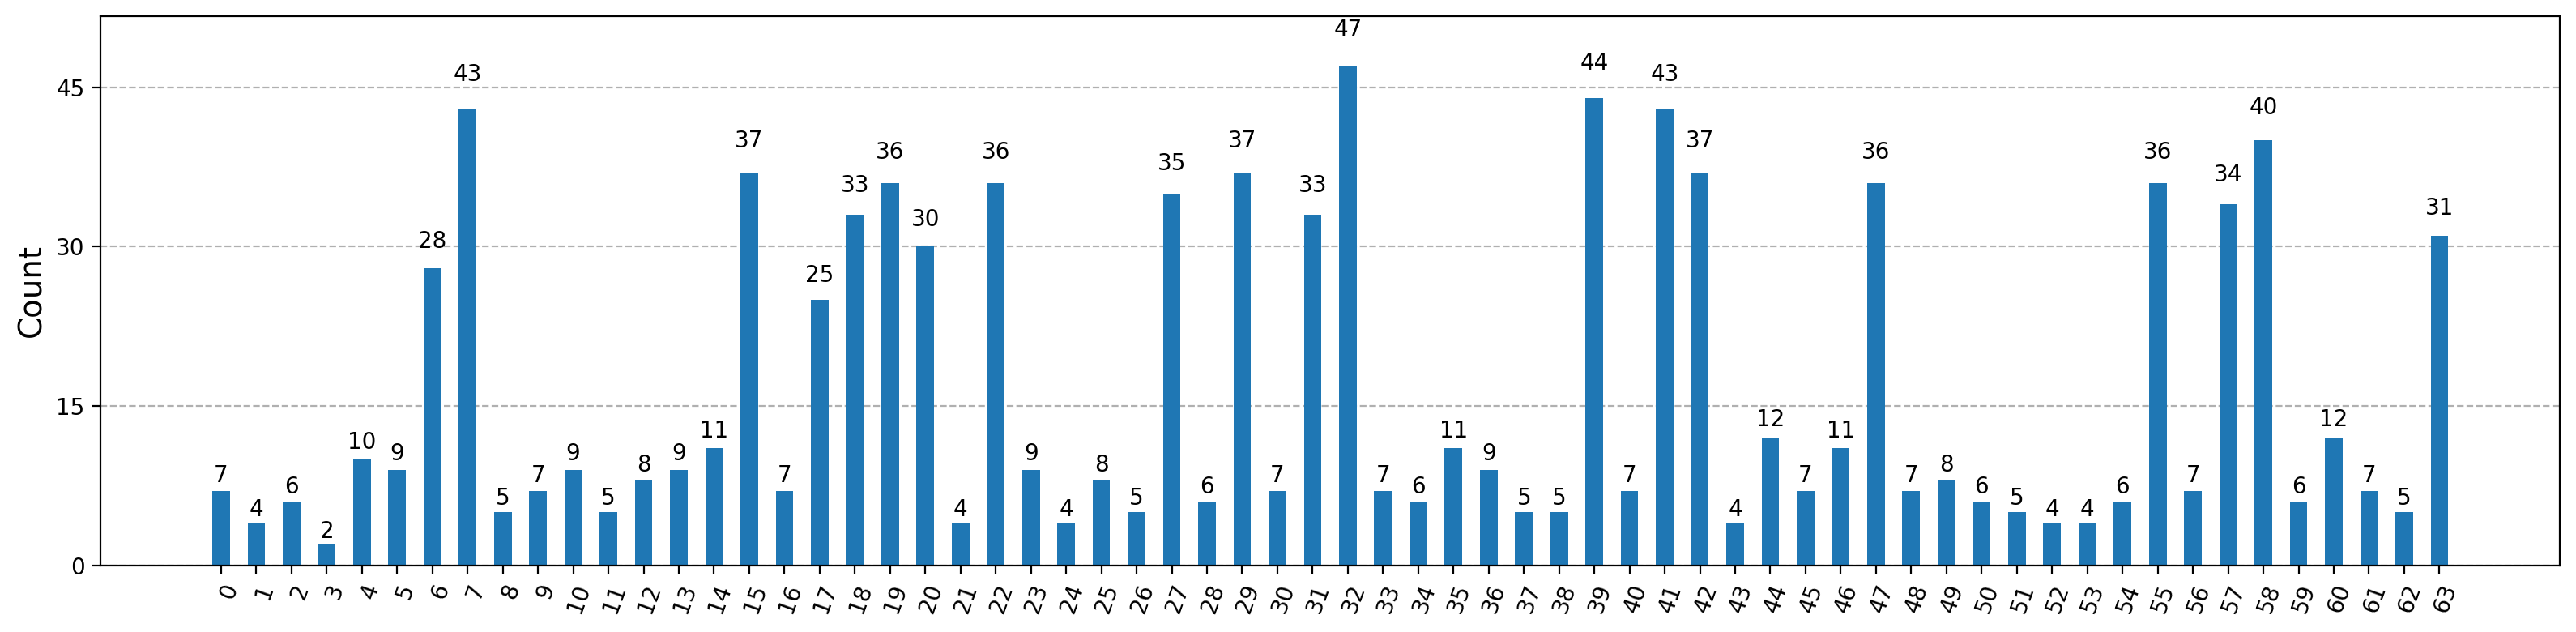

In [ ]:
# qc = generate_field(['000011', '000100', '010000', '001010'])
# qc = generate_field(positions)

qc = QuantumCircuit(6)
qc.h(range(6))

# grover_op = grover_operator(create_multi_target_oracle(['100000', '111111']))
# grover_op = grover_operator(create_multi_target_oracle(positions))
grover_op = grover_operator_custom(create_multi_target_oracle(positions))

for i in range(3):
  qc.append(grover_op, range(6))

qc.measure_all()

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()

counts = result.get_counts()
labels = [int(el, 2) for el in set(positions)]
labels.sort()
print(labels)
plot_histogram({int(el, 2) : val for el, val in counts.items()}, figsize=(16, 4))

In [ ]:
from qiskit.quantum_info import Operator

In [ ]:
e = np.pi / 100
rotations = int(np.pi / (2*e))
shots = 1024


def elitzur_vaidman(bomb):
    measurements = rotations + 1 if bomb else 1
    circuit = QuantumCircuit(1, measurements)

    rotate = Operator([
        [np.cos(e), -np.sin(e)],
        [np.sin(e), np.cos(e)]])

    for i in range(rotations):
        circuit.unitary(rotate, [0], label='Re')
        if bomb:
            circuit.measure(0, i)

    circuit.measure(0, measurements - 1)


    simulator = AerSimulator()
    compiled_circuit = transpile(circuit, simulator)
    job = simulator.run(compiled_circuit, shots=shots)
    result = job.result()
    counts = result.get_counts()
    # print(counts)
    predict_bomb = predict_no_bomb = blown_up = 0
    if bomb:
        predict_bomb = counts['0' * measurements]
        zeros_one = '0' * (measurements - 1) + '1'
        predict_no_bomb = counts[zeros_one] if zeros_one in counts else 0
        blown_up = shots - predict_bomb - predict_no_bomb
    else:
        predict_bomb = counts['0'] if '0' in counts else 0
        predict_no_bomb = counts['1']
        blown_up = 0

    y_pos = np.arange(3)
    plt.bar(y_pos, [predict_bomb, predict_no_bomb, blown_up])
    plt.xticks(y_pos, ['Predicts bomb', 'Predicts no bomb', 'Blown up'])
    plt.ylabel('Trials')
    plt.title('Elitzur-Vaidman results with' +
              (' ' if bomb else ' no ') + 'bomb')
    print(counts)
    plt.show()

{'0': 2, '1': 1022}


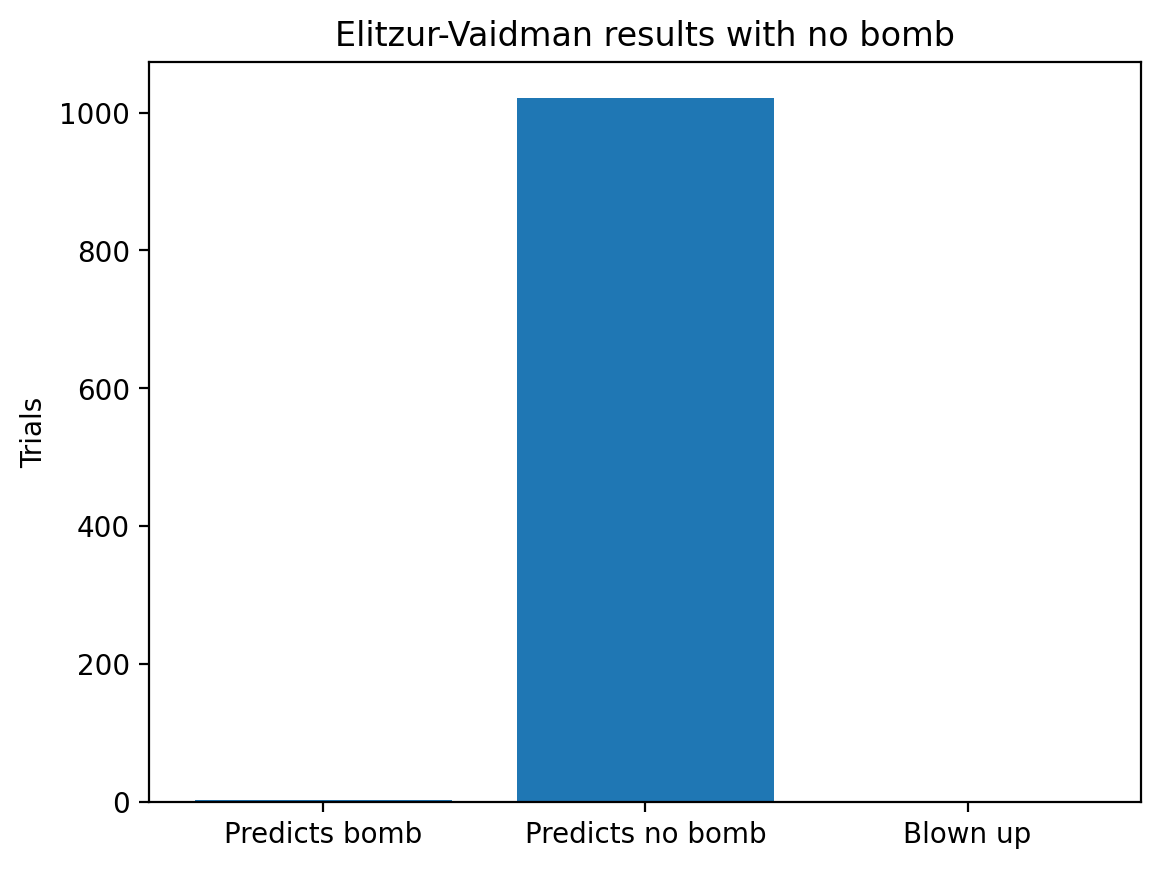

In [ ]:
elitzur_vaidman(False)

Doing rotations=20
{'000000 000001111000000000000': 1, '110000 010000000000000000000': 1, '100000 011100000000000000000': 3, '100010 010000000000000000000': 1, '100000 011111111111111111100': 5, '110000 011000000000000000000': 1, '010000 000001111111000000000': 1, '110000 011100000000000000000': 1, '000000 000000000000000000000': 721, '100000 011000000000000000000': 3, '000000 000000001000000000000': 1, '100000 011111100000000000000': 4, '100000 011111000000000000000': 7, '010000 000011111111100000000': 1, '100000 011111111111110000000': 7, '110000 011111111110000000000': 1, '110000 011111111111000000000': 1, '100010 011111111111000000000': 2, '110000 011111111111111000000': 1, '010010 000000000000000000000': 13, '100000 011111111000000000000': 4, '100000 011111111111111100000': 4, '100000 011111111100000000000': 4, '100000 011111111111100000000': 2, '010000 000000000000000000000': 104, '100000 011111111111111111000': 2, '100010 011111000000000000000': 1, '110010 011111111111111000000'

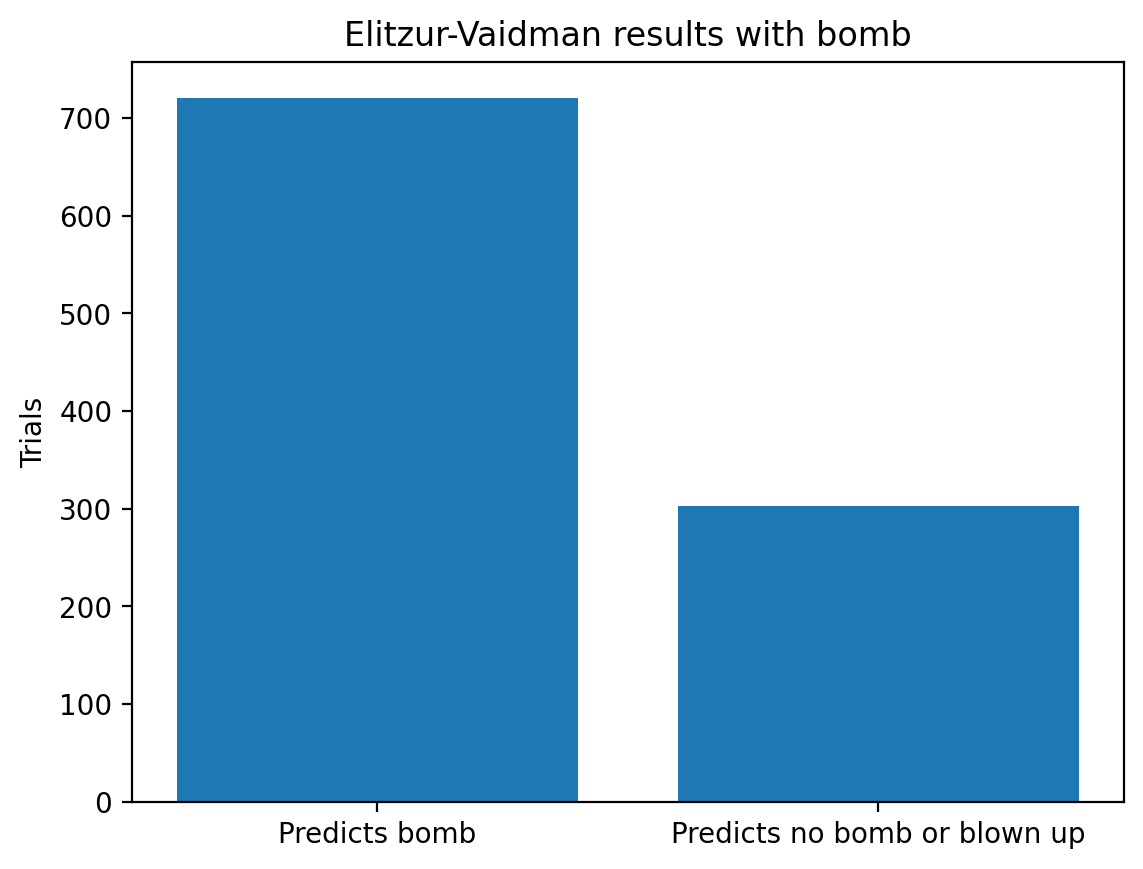

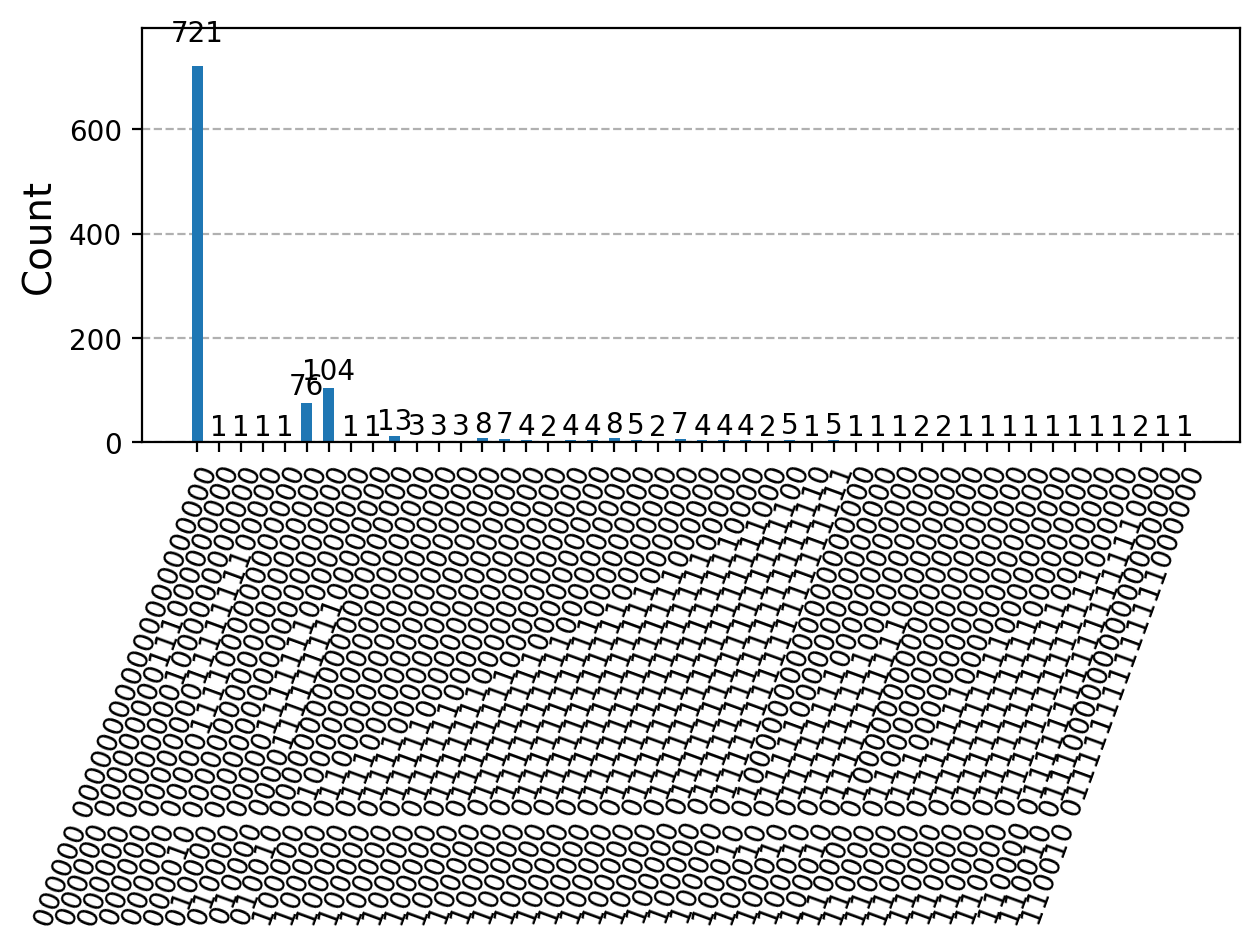

In [ ]:
e = np.pi / 40 # Small!
rotations = int(np.pi / (2*e))

print(f"Doing {rotations=}")

def elitzur_vaidman(bomb, positions: list[str]):

    measurements = rotations + 1 if bomb else 1

    circuit = QuantumCircuit(6, measurements)

    rotate = Operator([
        [np.cos(e), -np.sin(e)],
        [np.sin(e), np.cos(e)]]
    ) # cos(e)|0> + sin(e)|1>
    # measure (have bomb) -> sin^2(e)|1> + cos^2(e)|0> --loop--> cos^{2T}(e)|0> = |0>
    # no bomb -> cos(Te)|0> + sin(Te)|1> --(Te ~ pi/2)--> |1>

    for i in range(rotations):
      qubits_to_rotate = []
      for position in positions:
        for j, pos in enumerate(position):
          if pos == "1":
            # circuit.unitary(rotate, [j], label='Re')
            qubits_to_rotate.append(j)
            # if bomb:
            #     circuit.measure(j, i)
      for qubit in set(qubits_to_rotate):
        circuit.unitary(rotate, [qubit], label='Re')
        if bomb:
            circuit.measure(qubit, i)
    circuit.measure_all()
    return circuit, measurements, bomb

position = '010011'
circuit, measurements, bomb = elitzur_vaidman(True, [position,])

simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
predict_bomb = predict_no_bomb = 0
if bomb:
  predict_bomb = counts['0' * len(position) + ' ' + '0' * measurements]
  # blown_up = 1024 - predict_bomb
  zeros_one = '0' * (measurements - 1) + '1'
  predict_no_bomb = counts[zeros_one] if zeros_one in counts else 0
  blown_up = 1024 - predict_bomb - predict_no_bomb
else:
  predict_no_bomb = counts[list(counts.keys())[0]]
  predict_bomb = 1024 - predict_no_bomb
  blown_up = 0

y_pos = np.arange(2)
plt.bar(y_pos, [predict_bomb, predict_no_bomb + blown_up])
plt.xticks(y_pos, ['Predicts bomb', 'Predicts no bomb or blown up'])
plt.ylabel('Trials')
plt.title('Elitzur-Vaidman results with' +
          (' ' if bomb else ' no ') + 'bomb')

plt.show()
plot_histogram(counts)

Doing rotations=5
{'011001': 2, '001011': 2, '010100': 6, '010110': 2, '001100': 6, '000100': 70, '010000': 59, '000000': 596, '000010': 75, '011100': 1, '010010': 6, '000001': 72, '011000': 9, '001010': 4, '001000': 71, '000110': 9, '001001': 9, '010001': 6, '000101': 10, '000111': 2, '000011': 7}


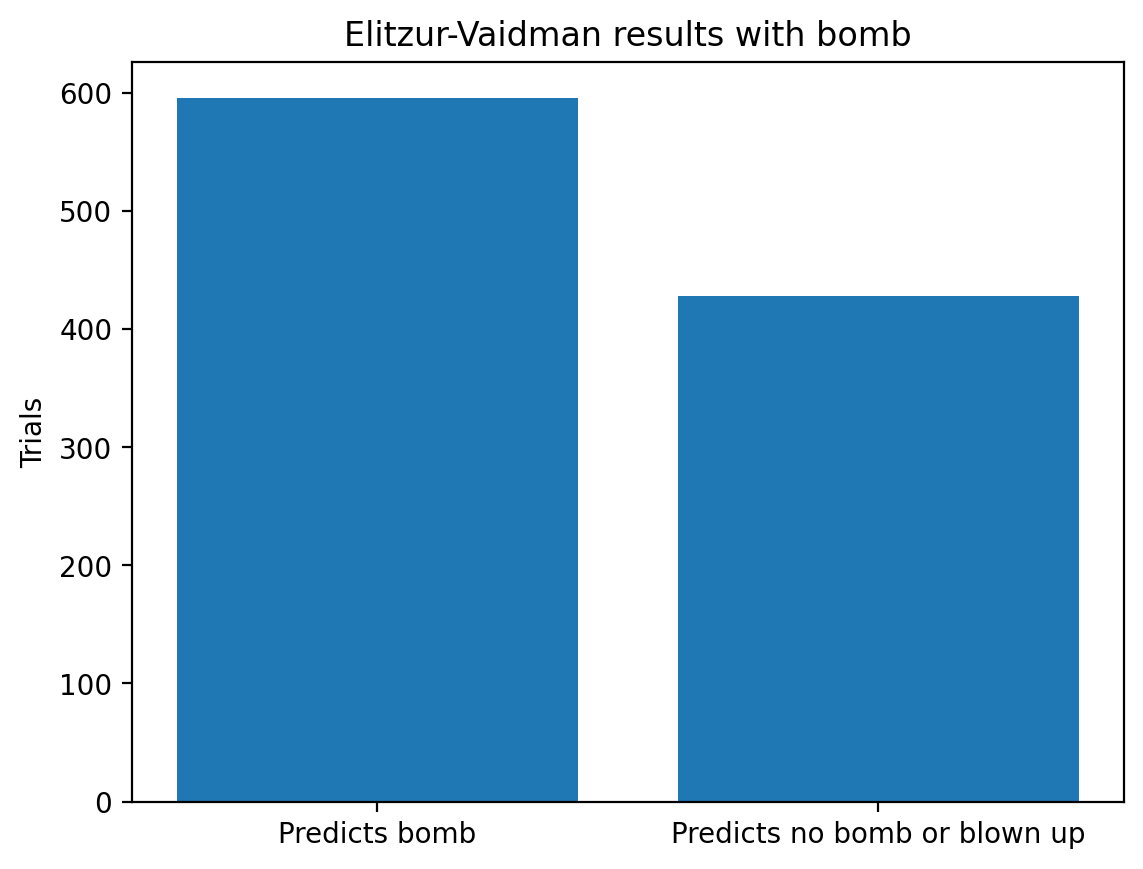

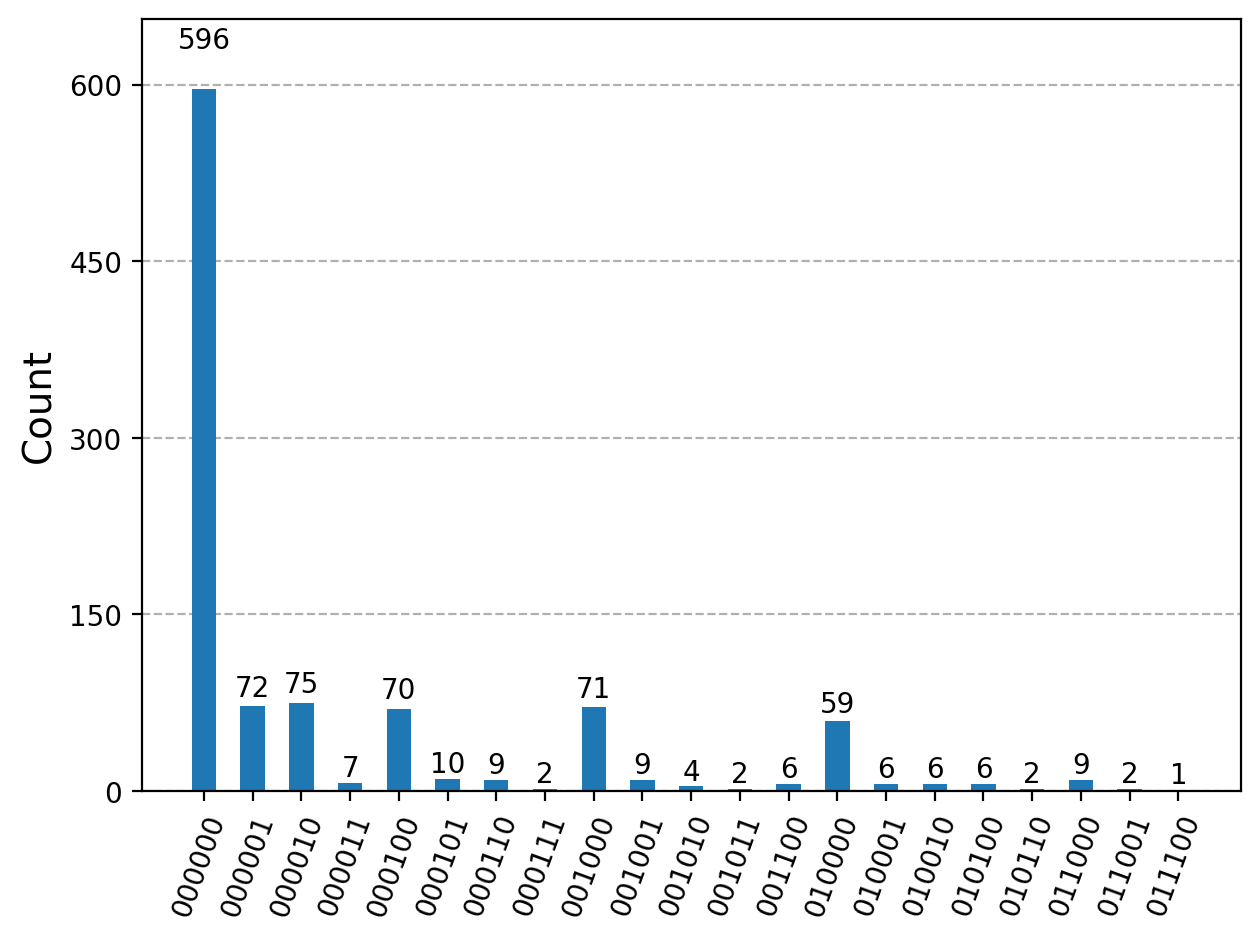

In [ ]:
e = np.pi / 10 # Small!
rotations = int(np.pi / (2*e))

print(f"Doing {rotations=}")

def elitzur_vaidman(bomb_pos, positions: list[str]):
    qc = QuantumCircuit(7, rotations + 1)

    for pos in position:
      for i, bit in enumerate(pos):
        if bit == '1': qc.x(i)

    for i in range(rotations):
      qc.ry(2 * e, 6)
      # cos(e)|0> + sin(e)|1>
      # measure (have bomb) -> sin^2(e)|1> + cos^2(e)|0> --loop--> cos^{2T}(e)|0> = |0>
      # no bomb -> cos(Te)|0> + sin(Te)|1> --(Te ~ pi/2)--> |1>

      for pos in positions:
        if pos == bomb_pos:
          qc.measure(6, i)
          qc.reset(6)

    qc.measure(6, rotations)
    return qc

position = '010011'
qc = elitzur_vaidman('010011', [position,])

simulator = AerSimulator()
compiled_circuit = transpile(qc, simulator)
job = simulator.run(compiled_circuit, shots=1024)
result = job.result()
counts = result.get_counts()
print(counts)
predict_bomb = predict_no_bomb = 0
predict_bomb_key = '0' * (rotations + 1)
if predict_bomb_key in counts:
  predict_bomb = counts[predict_bomb_key]
  blown_up = 1024 - predict_bomb
else:
  predict_no_bomb = counts[list(counts.keys())[0]]
  predict_bomb = 1024 - predict_no_bomb
  blown_up = 0

y_pos = np.arange(2)
plt.bar(y_pos, [predict_bomb, predict_no_bomb + blown_up])
plt.xticks(y_pos, ['Predicts bomb', 'Predicts no bomb or blown up'])
plt.ylabel('Trials')
plt.title('Elitzur-Vaidman results with' +
          (' ' if bomb else ' no ') + 'bomb')

plt.show()
plot_histogram(counts)

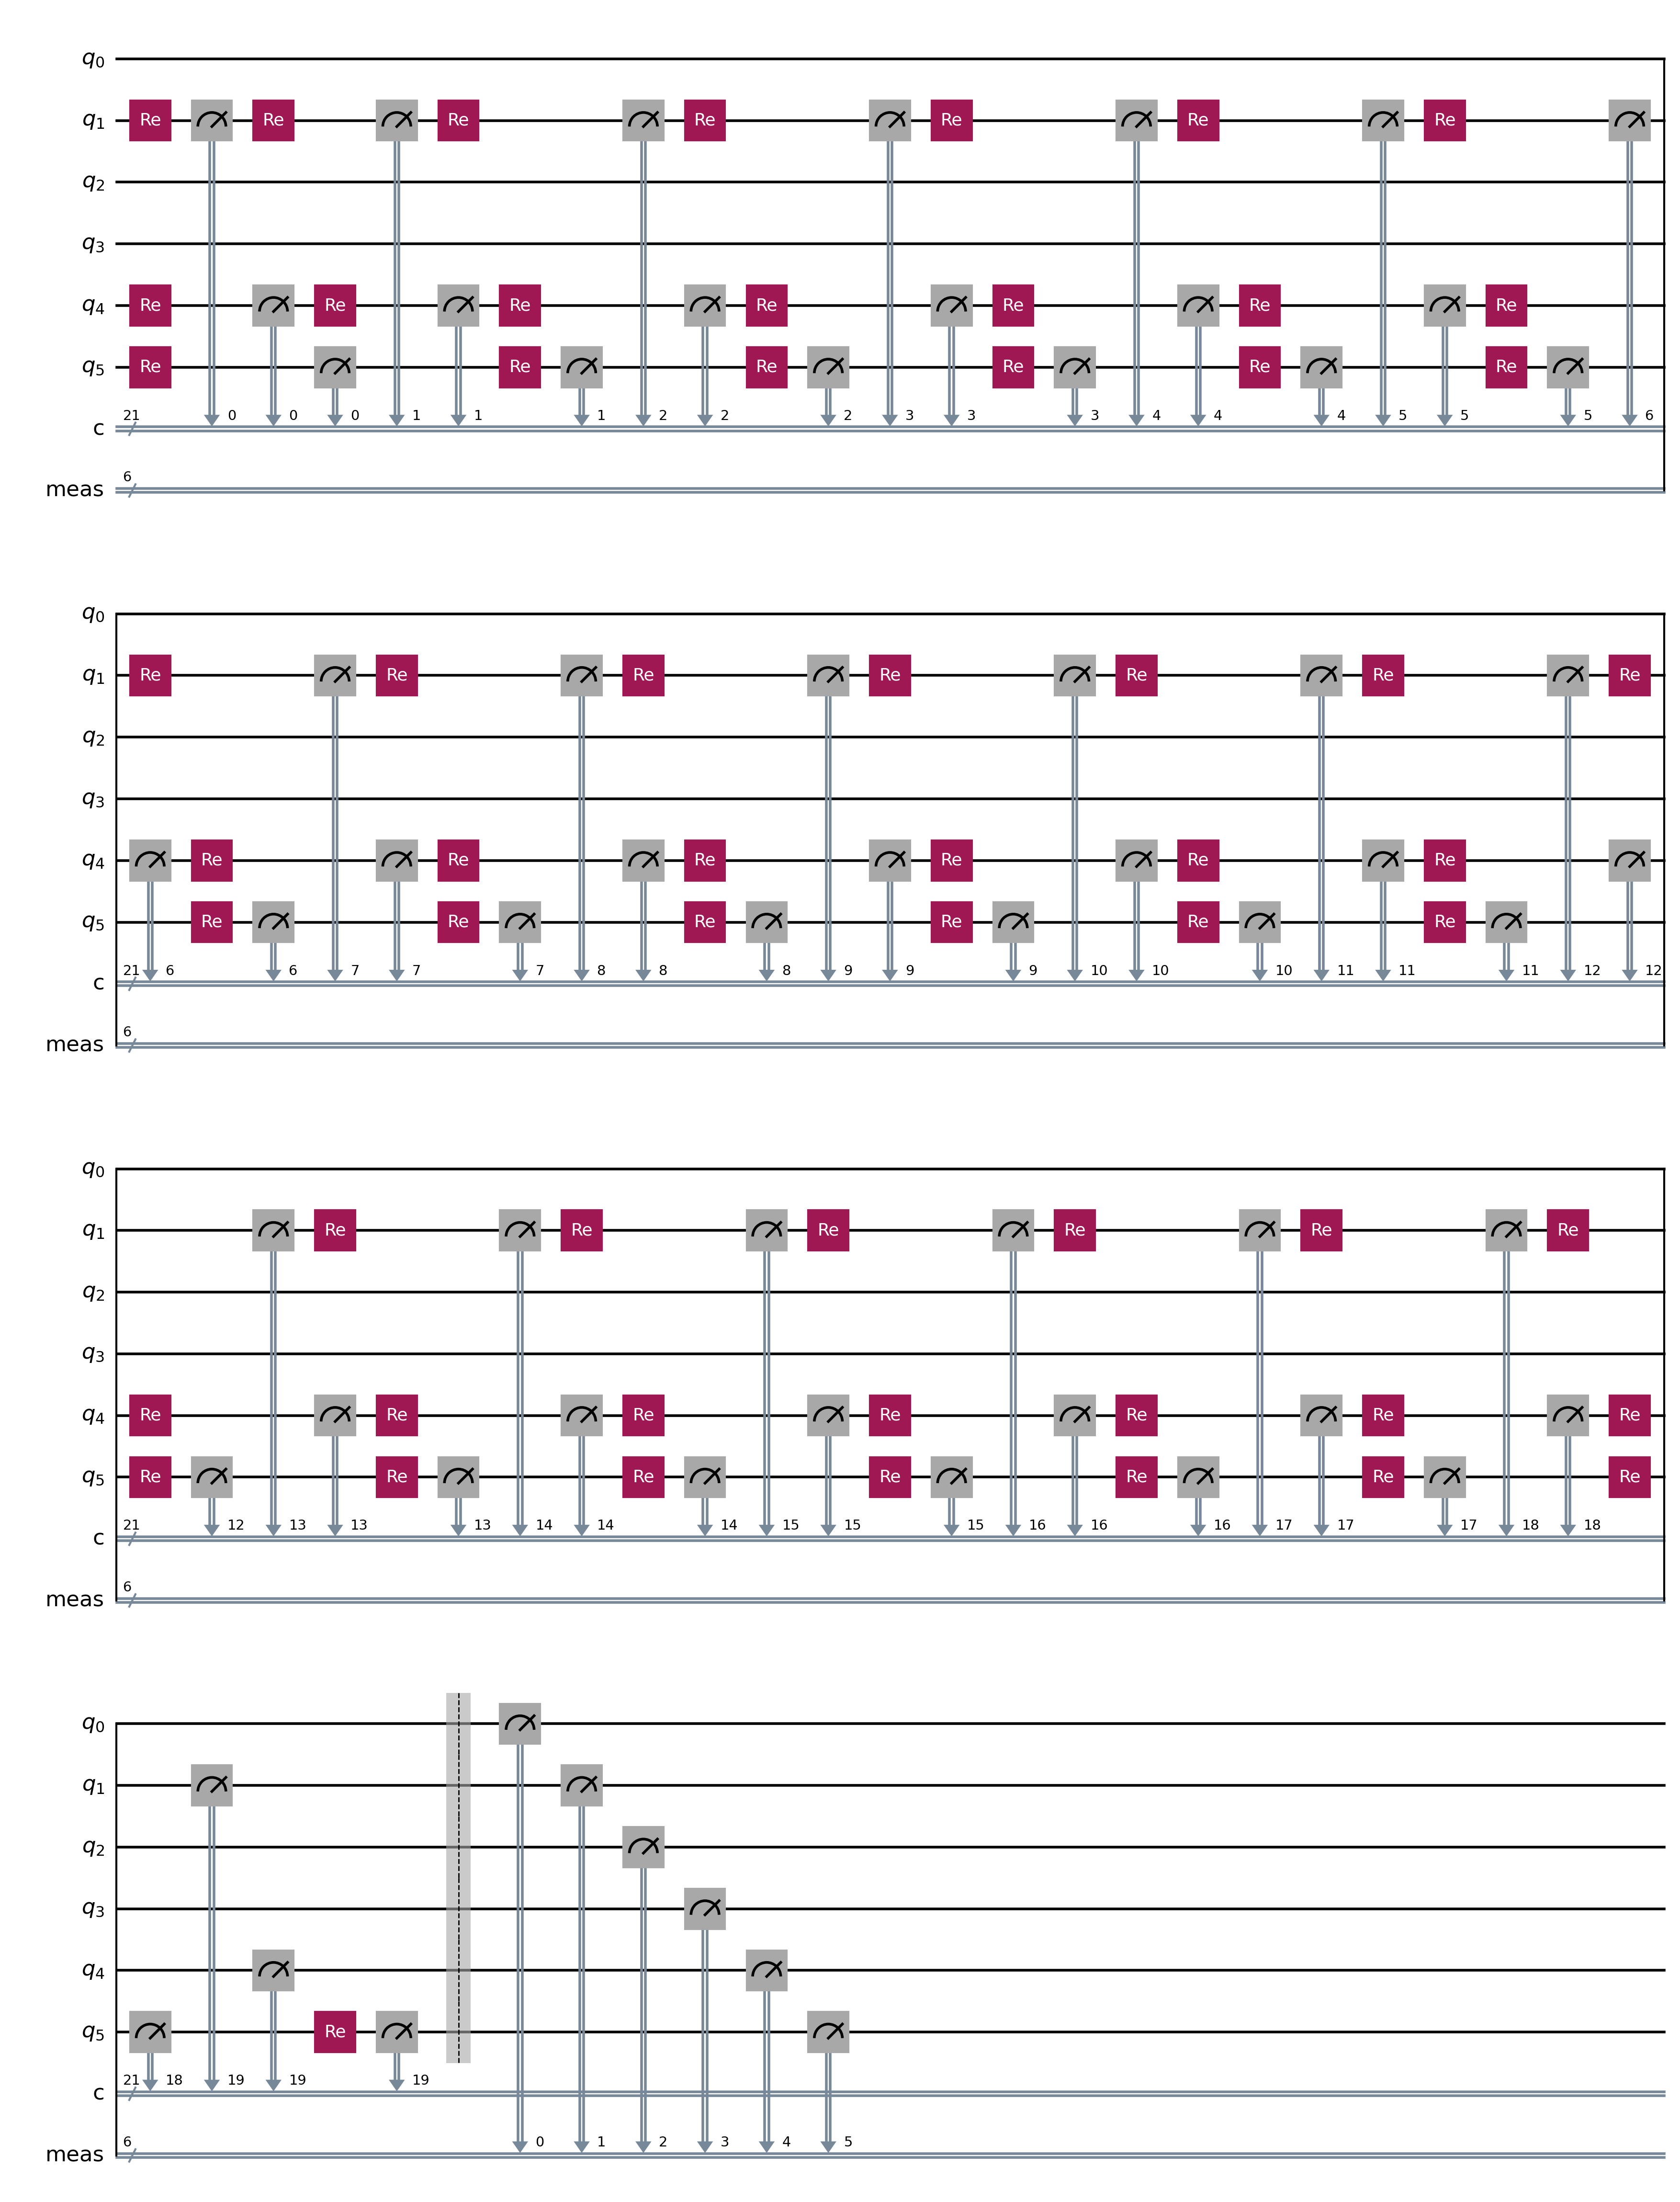

In [ ]:
display(circuit.draw('mpl'))

# Build and run your quantum circuit

# How well did your algorithm do?

* Find a way to represent your results in a way that you can compare to the original game board
* Choose a way to quantify how well your quantum implementation did compared to a classical search